20251105 Levi Schult -- a notebook to create a chirpmass KDE for synthesizing 
the CV population in the EM gap. This KDE will be used in addition to the 
equation for GW evolution and the number in the flo bin to determine number of
sources in the EM gap.

In [1]:
import numpy as np
from scipy import stats, interpolate
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as apyconst
import pandas as pd
import legwork as lw
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import copy


%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt'
CV_pop = pd.read_csv(file)

In [3]:
CV_pop.columns

Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_gal[kpc]', ' y_gal[kpc]', ' z_gal[kpc]', ' Pala_reassigned'],
      dtype='object')

Text(0.5, 0, 'Freq [Hz]')

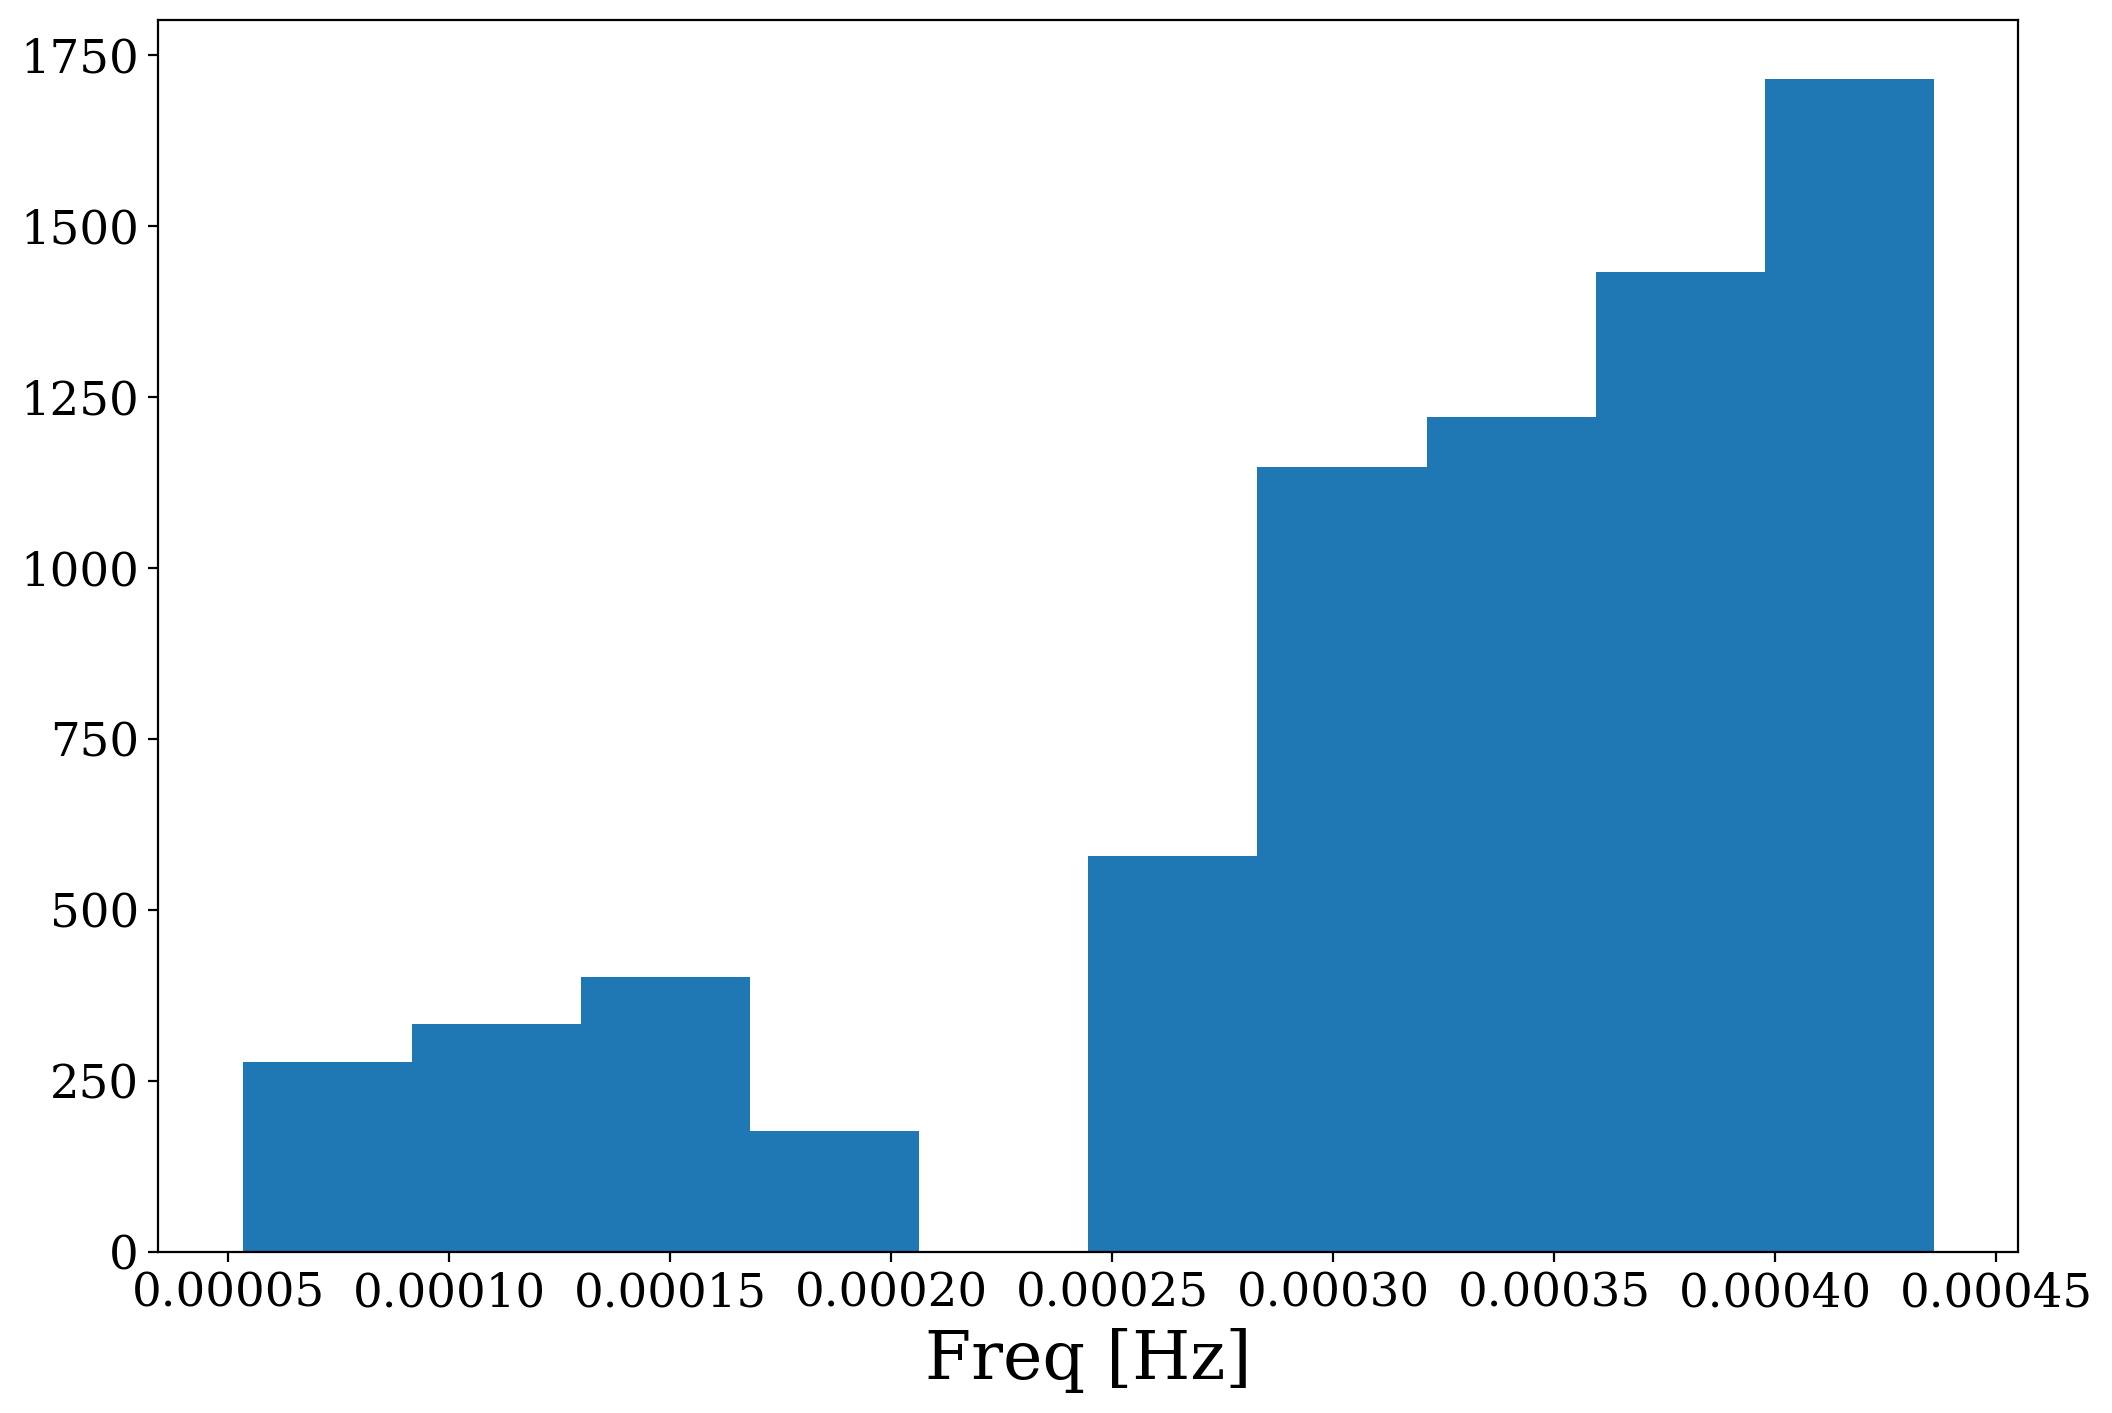

In [4]:
fhist = plt.hist(CV_pop[' f_gw[Hz]'])
plt.xlabel('Freq [Hz]')

In [5]:
counts, bins = fhist[0], fhist[1]
print(counts)

[ 277.  333.  402.  177.    0.  579. 1147. 1221. 1433. 1715.]


In [6]:
# Grabbing indices for flo and fhi from seeing the edges of 0 region in counts
# ind_flo = np.where(counts==56)[0][0] # LSS bins = auto
ind_flo = np.where(counts==177)[0][0]
# ind_fhi = np.where(counts==97)[0][0] # LSS bins = auto
ind_fhi = np.where(counts==579)[0][0]


# getting flo, fhi, number of CVs in each
N_flo = counts[ind_flo]
N_fhi = counts[ind_fhi]

flo = bins[ind_flo]
fhi = bins[ind_fhi]

In [7]:
# LSS picking out the CVs at flo and fhi. will use flo ones to make chirp mass 
# dist. 
df = (flo-bins[ind_flo-1])
flo_CVs_ind = np.where((CV_pop[' f_gw[Hz]']>bins[ind_flo]) &
                    (CV_pop[' f_gw[Hz]']<bins[ind_flo]+df))[0]
print(flo_CVs_ind.shape)
fhi_CVs_ind = np.where((CV_pop[' f_gw[Hz]']>bins[ind_fhi]) &
                    (CV_pop[' f_gw[Hz]']<bins[ind_fhi]+df))[0]
print(fhi_CVs_ind.shape)

(177,)
(579,)


In [8]:
flo_CVs_ind

array([  40,   51,  191,  198,  247,  303,  388,  394,  411,  462,  478,
        482,  491,  511,  594,  672,  719,  748,  773,  809,  831,  842,
        843,  871,  900,  929, 1030, 1050, 1055, 1067, 1209, 1288, 1291,
       1305, 1315, 1325, 1341, 1365, 1417, 1468, 1506, 1512, 1525, 1578,
       1617, 1644, 1645, 1679, 1732, 1793, 1800, 1836, 1843, 1852, 1881,
       1889, 1946, 2009, 2038, 2069, 2200, 2207, 2213, 2262, 2264, 2311,
       2313, 2328, 2352, 2426, 2502, 2562, 2563, 2591, 2664, 2665, 2714,
       2832, 2848, 2911, 3044, 3120, 3124, 3181, 3252, 3269, 3535, 3542,
       3633, 3687, 3712, 3724, 3763, 3803, 3812, 3839, 3845, 3848, 3870,
       3879, 3893, 3973, 3981, 4031, 4037, 4048, 4104, 4125, 4147, 4152,
       4177, 4259, 4292, 4374, 4531, 4544, 4569, 4596, 4597, 4682, 4693,
       4706, 4720, 4733, 4781, 4799, 4920, 5051, 5066, 5091, 5099, 5201,
       5237, 5239, 5242, 5255, 5263, 5274, 5334, 5349, 5445, 5449, 5457,
       5461, 5522, 5530, 5550, 5597, 5599, 5682, 57

In [9]:
flo_CVs = CV_pop.iloc[flo_CVs_ind]
flo_mc = lw.utils.chirp_mass(flo_CVs['# m1[Msun]'] * u.Msun, flo_CVs[' m2[Msun]'] * u.Msun)


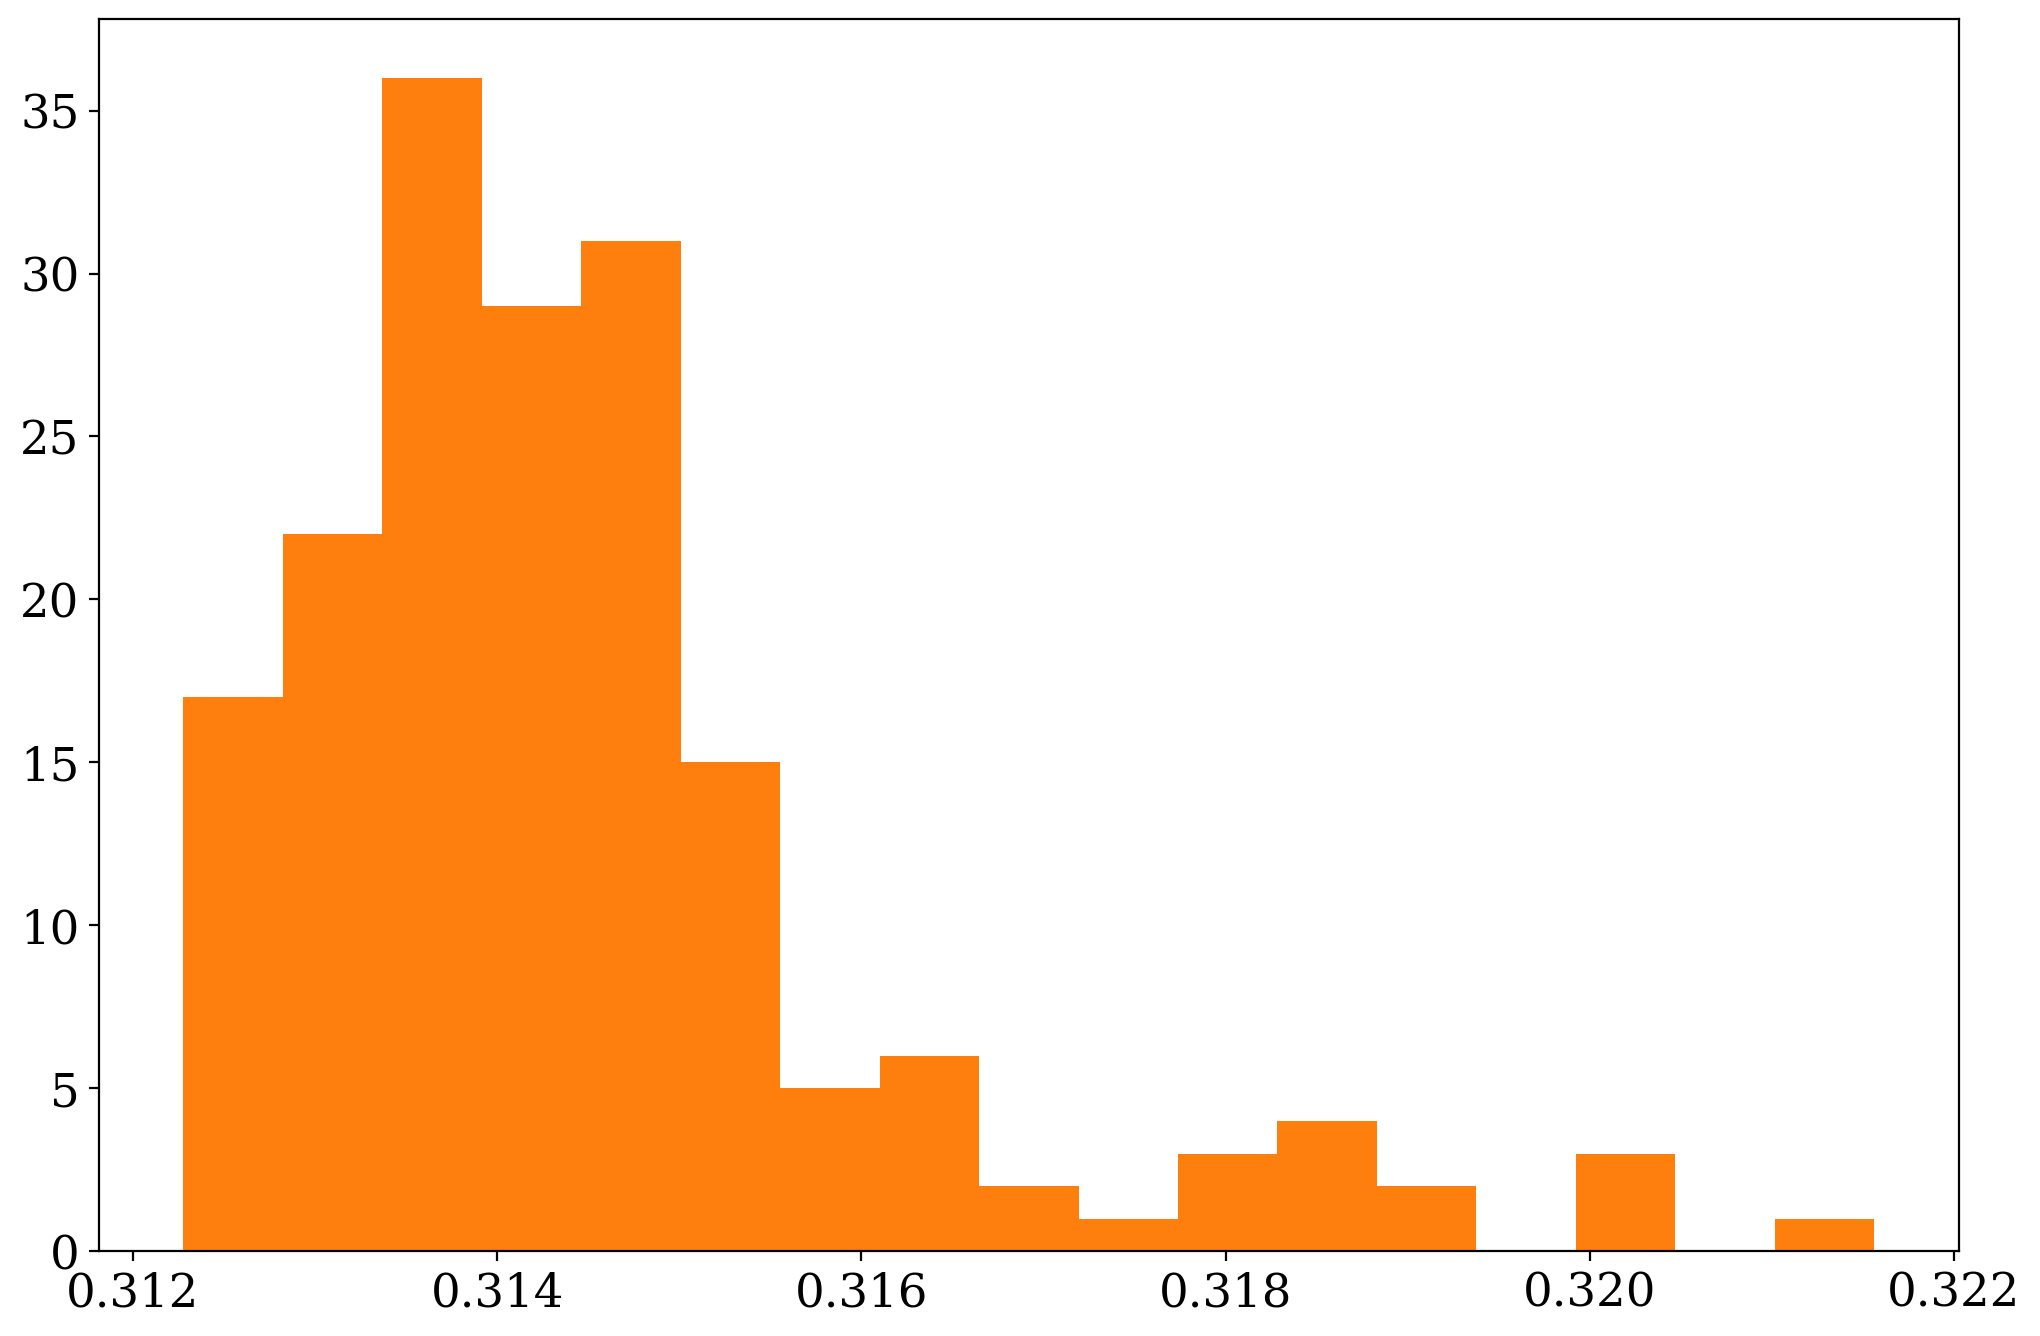

In [10]:
flo_mc_cts, flo_mc_bins = plt.hist(flo_mc, bins='auto')[0], plt.hist(flo_mc, bins='auto')[1]

(array([2., 0., 5., 0., 0., 2., 2., 1., 1., 1., 3., 4., 1., 5., 2., 3., 2.,
        0., 3., 2., 2., 3., 2., 3., 0., 3., 7., 1., 7., 4., 3., 4., 4., 4.,
        3., 2., 1., 2., 2., 3., 3., 4., 2., 1., 5., 3., 3., 3., 2., 3., 3.,
        4., 2., 0., 2., 2., 1., 0., 1., 3., 1., 2., 1., 0., 1., 1., 0., 1.,
        0., 0., 1., 1., 0., 2., 0., 1., 0., 0., 0., 1., 0., 0., 1., 2., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 0., 1., 0., 0., 1.,
        0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1.]),
 array([0.31227743, 0.31232989, 0.31238234, 0.3124348 , 0.31248725,
        0.31253971, 0.31259216, 0.31264462, 0.31269708, 0.31274953,
        0.31280199, 0.31285444, 0.3129069 , 0.31295935, 0.31301181

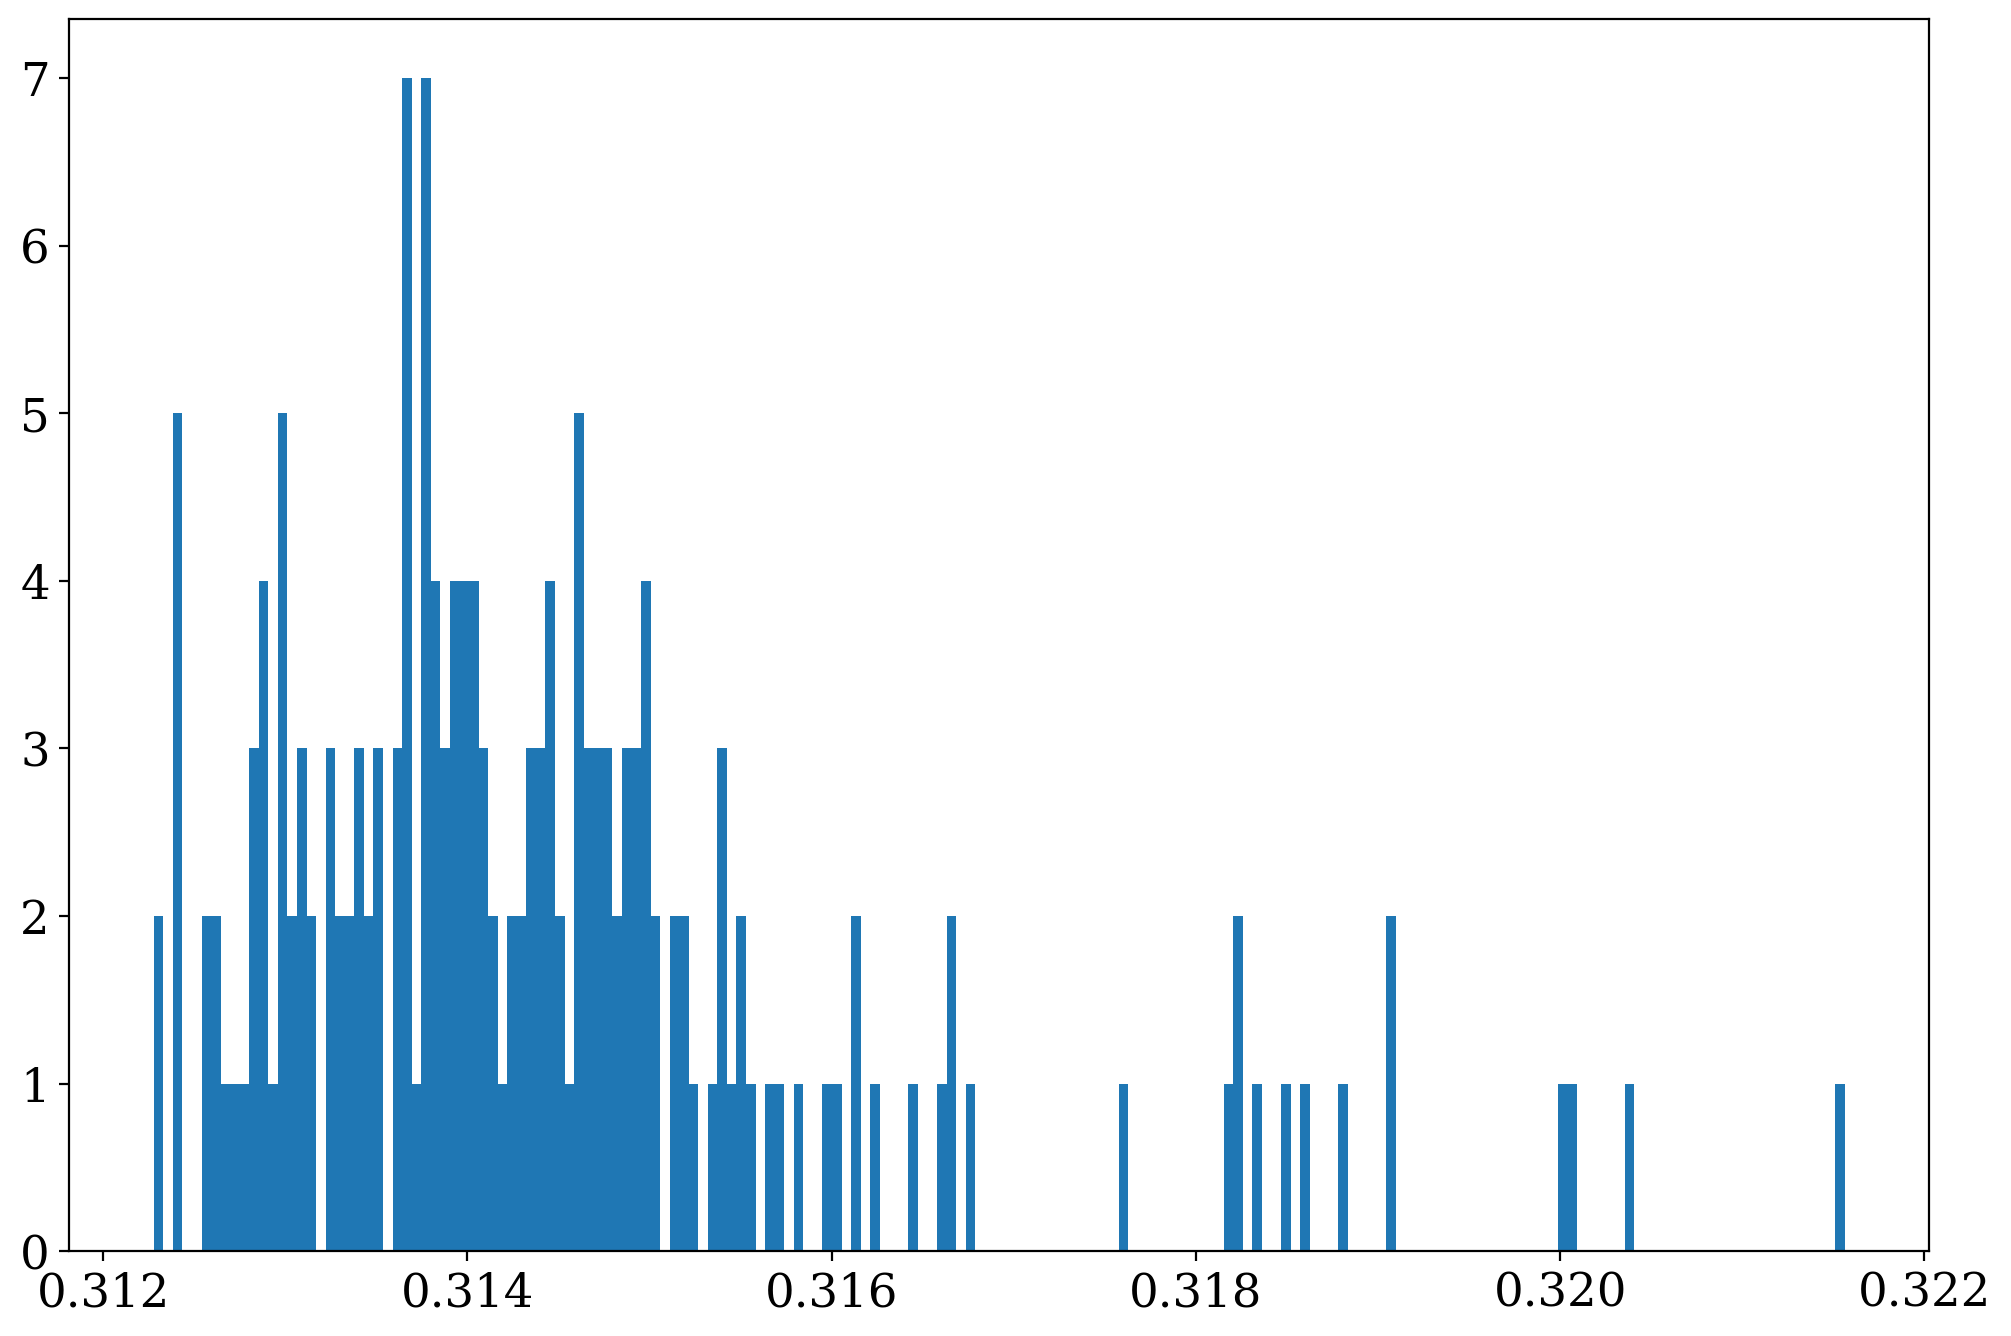

In [11]:
plt.hist(flo_mc, bins=len(flo_mc))

## now make the KDE of the flo chirp mass dist

In [12]:
kern = 'gaussian'

bwrange = np.linspace(1e-9, 1e-3, 1000) # Test 100 bandwidths from 0.1 to 1.0
K = 20 # Do 20-fold cross validation
grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) # Try each bandwidth with K-folds
grid.fit(np.array(flo_mc)[:, None]) #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.0006056060000000001


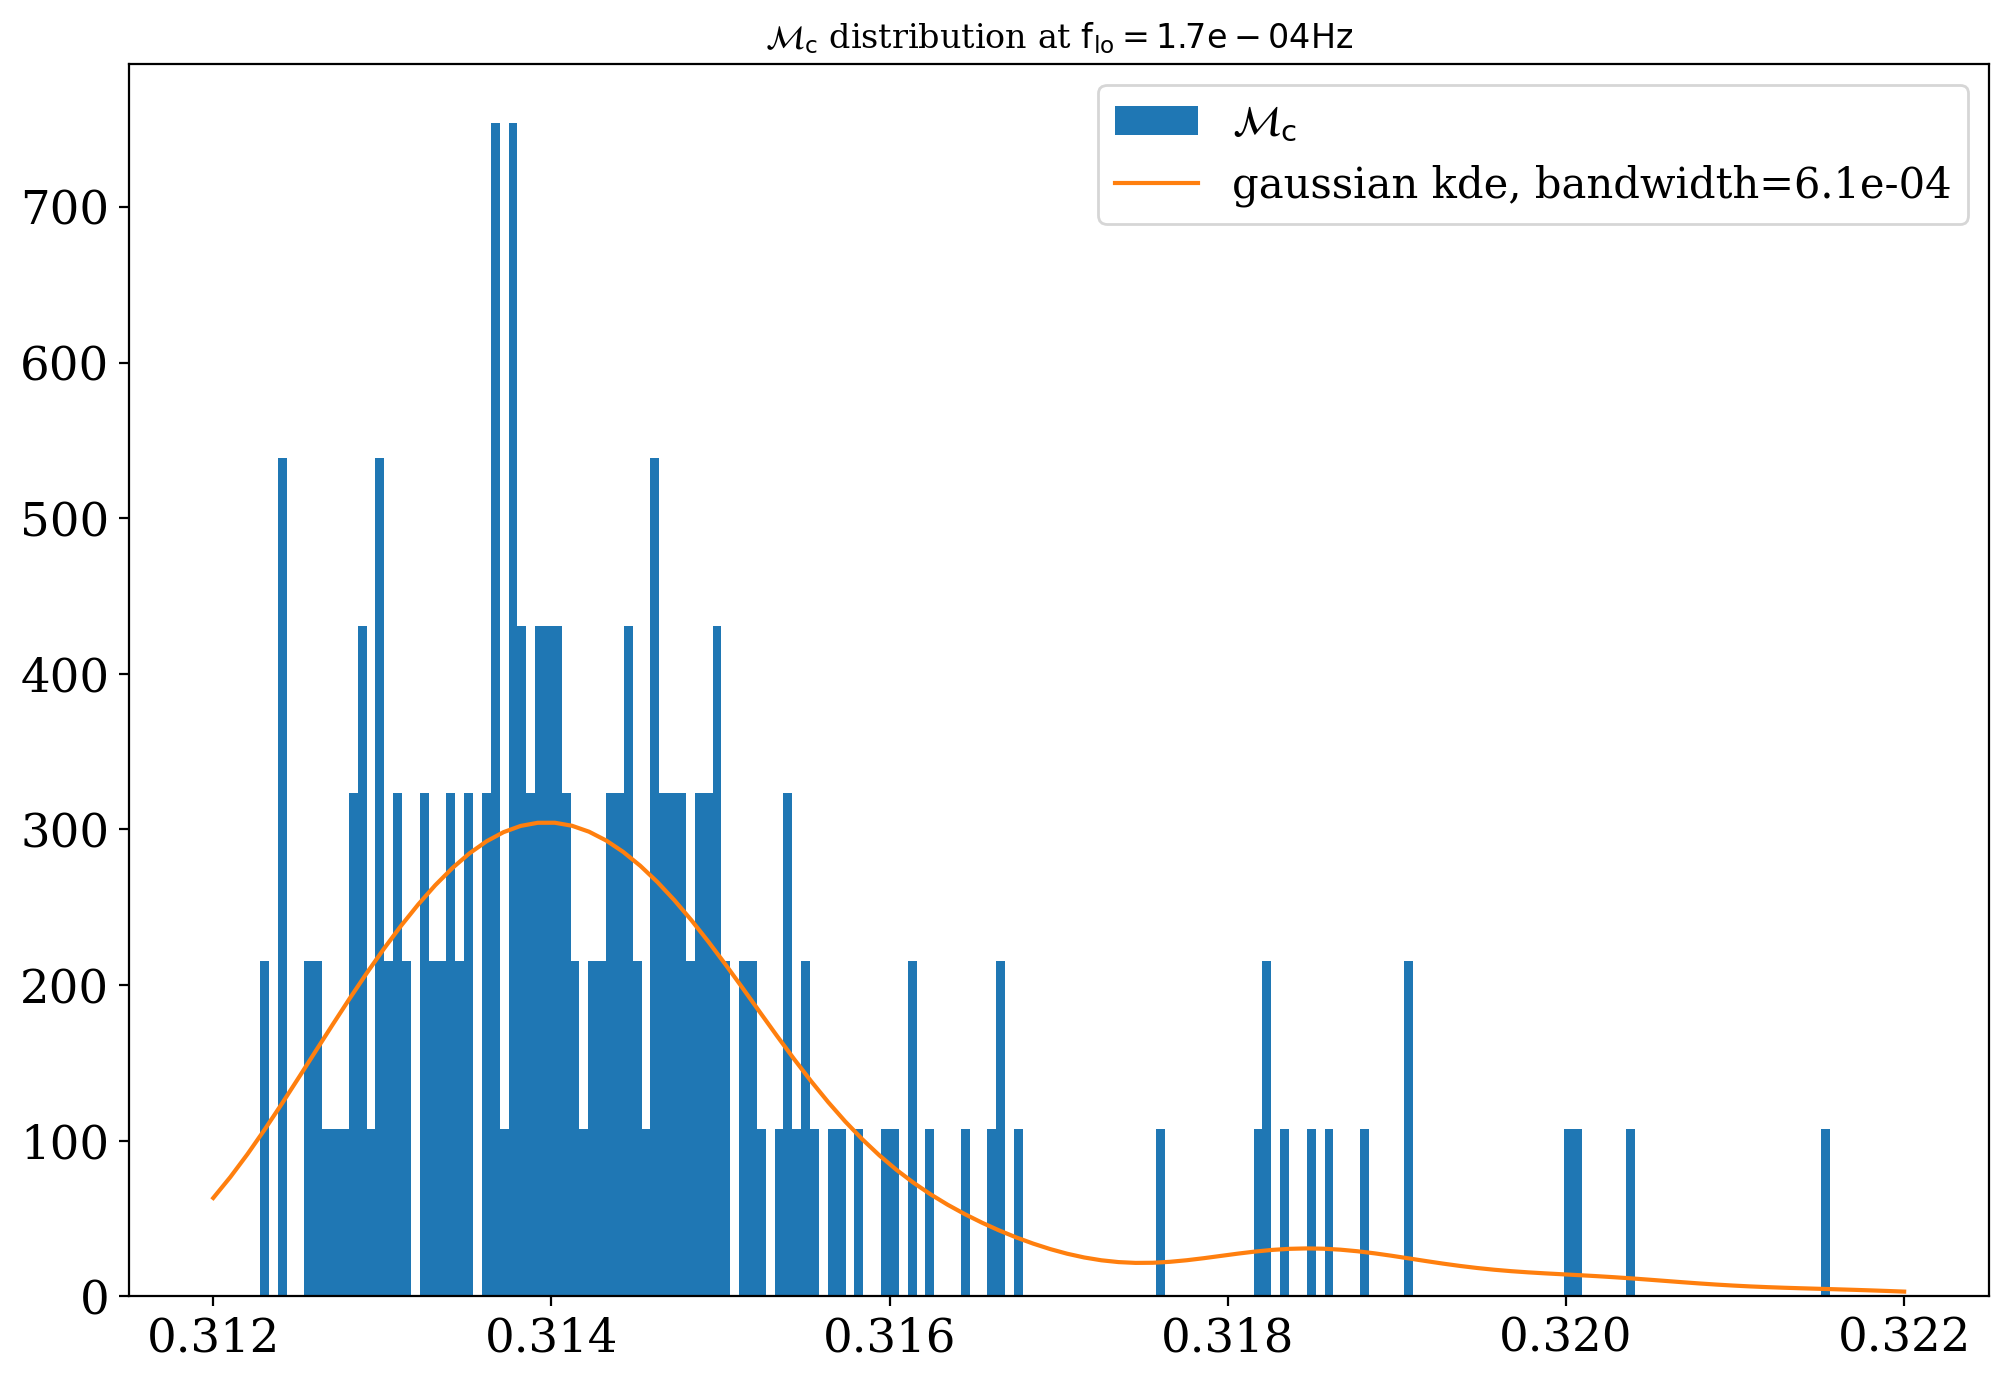

In [13]:
plt.title(rf'$\mathcal{{M}}_{{\rm c}}$ distribution at $\rm f_{{\rm lo}} = {flo:.1e} Hz$')
plt.hist(flo_mc, bins=len(flo_mc), label=r'$\mathcal{M}_{\rm c}$', density=True)
mc_range = np.linspace(0.312, 0.322, 100)
mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(flo_mc)[:, None])
log_dens = mc_kde.score_samples(mc_range[:, None])
# plt.plot(mc_range, np.exp(log_dens)*.01, label=f'cosine kde, bandwidth={h_opt:.1e}')
plt.plot(mc_range, np.exp(log_dens), label=f'{kern} kde, bandwidth={h_opt:.1e}')

plt.legend(fontsize=15)

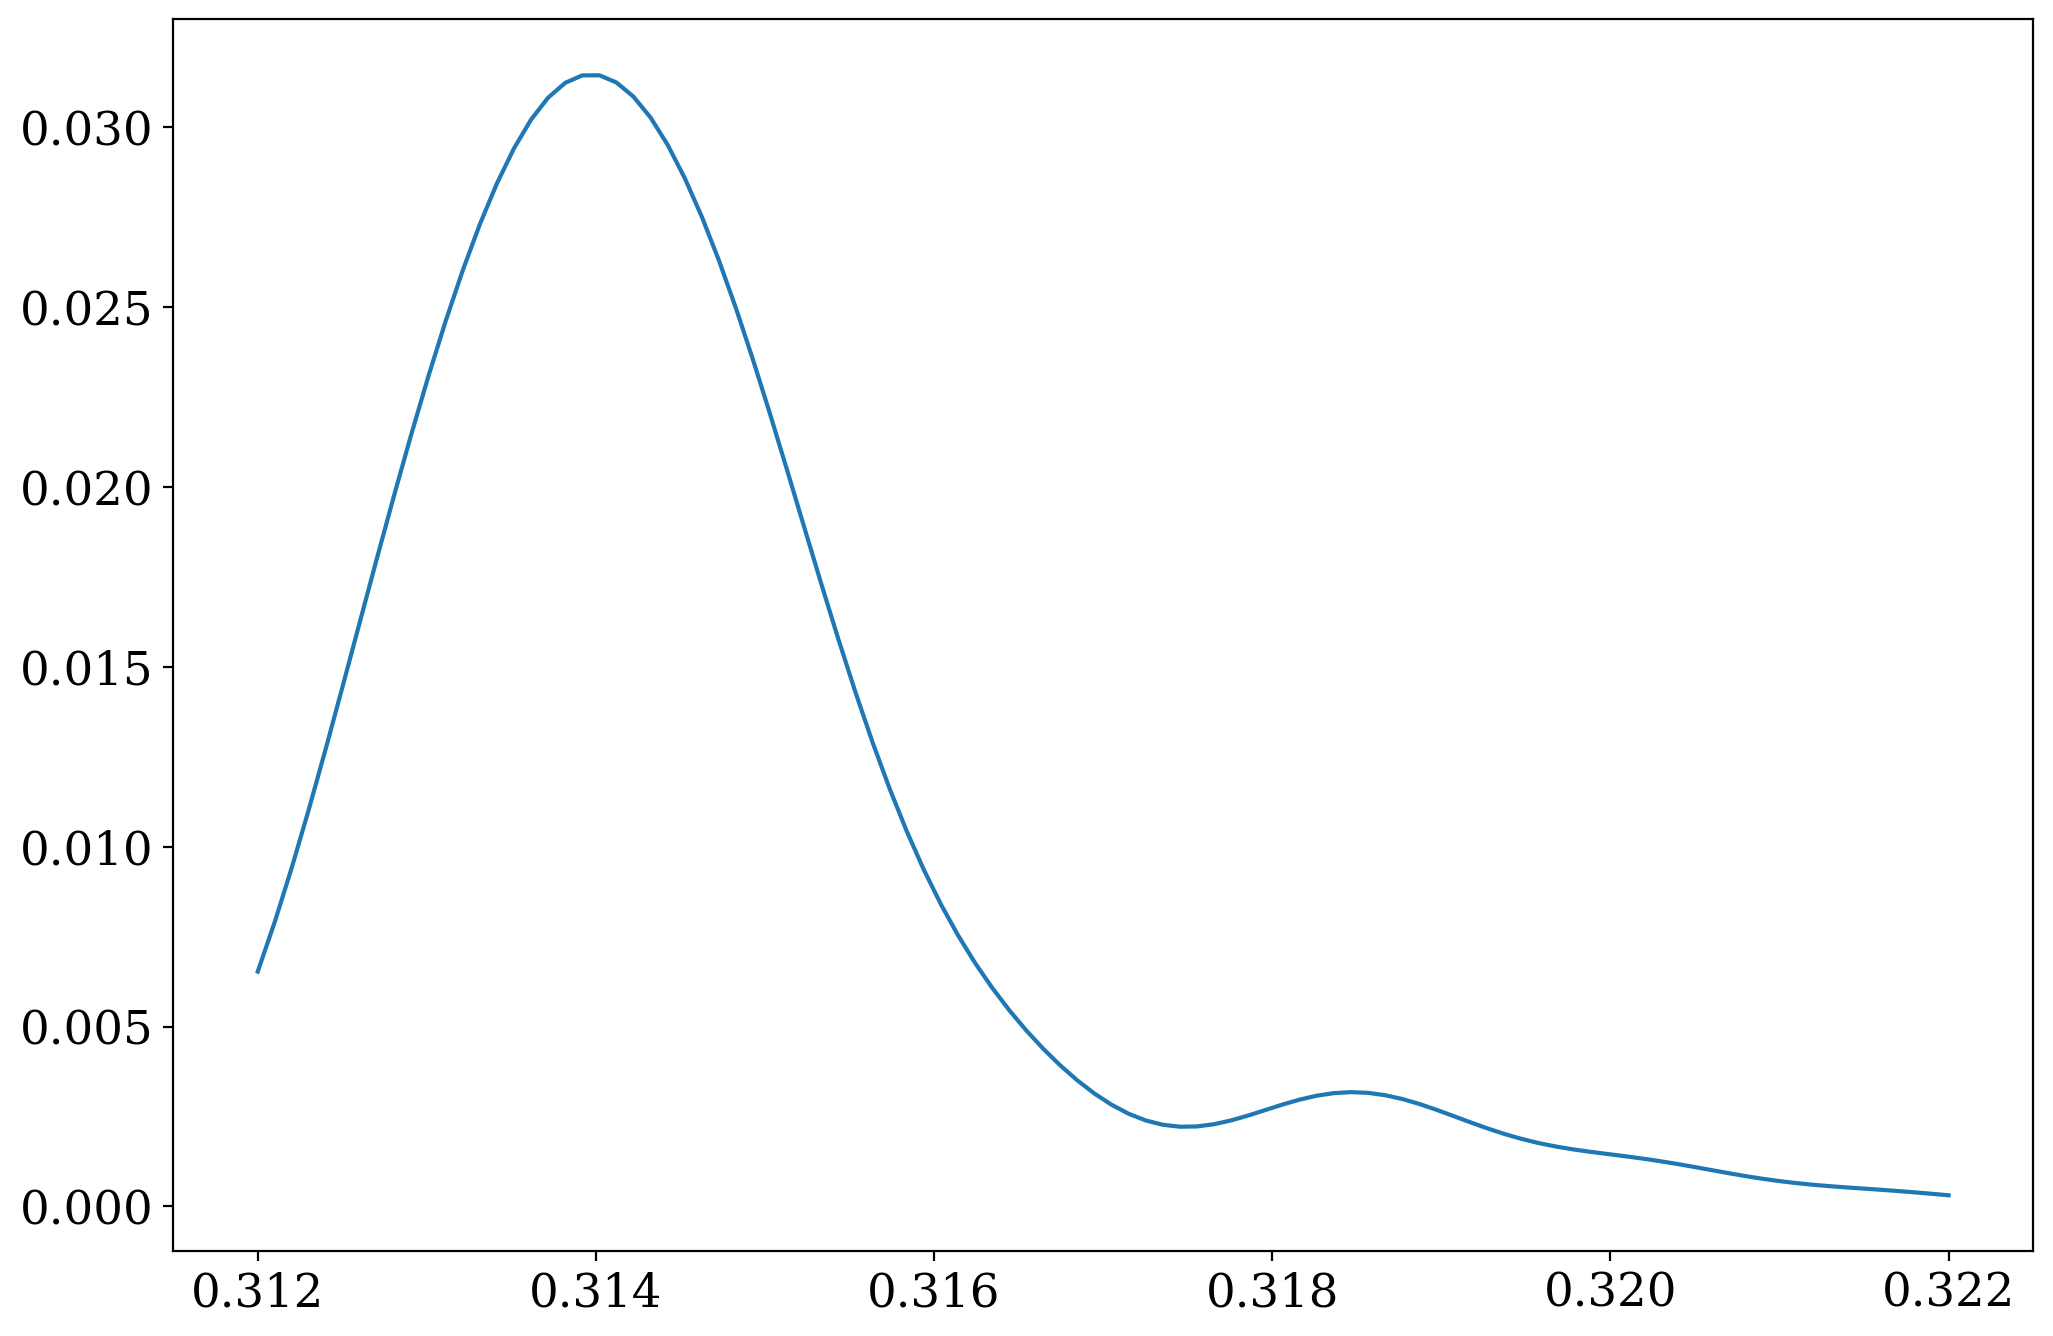

In [14]:
# normalize
plt.plot(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)), label=f'{kern} kde, bandwidth={h_opt:.1e}')

In [15]:
# fit the above likelihood values with interpolation 
mc_flo_interp = interpolate.interp1d(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)))

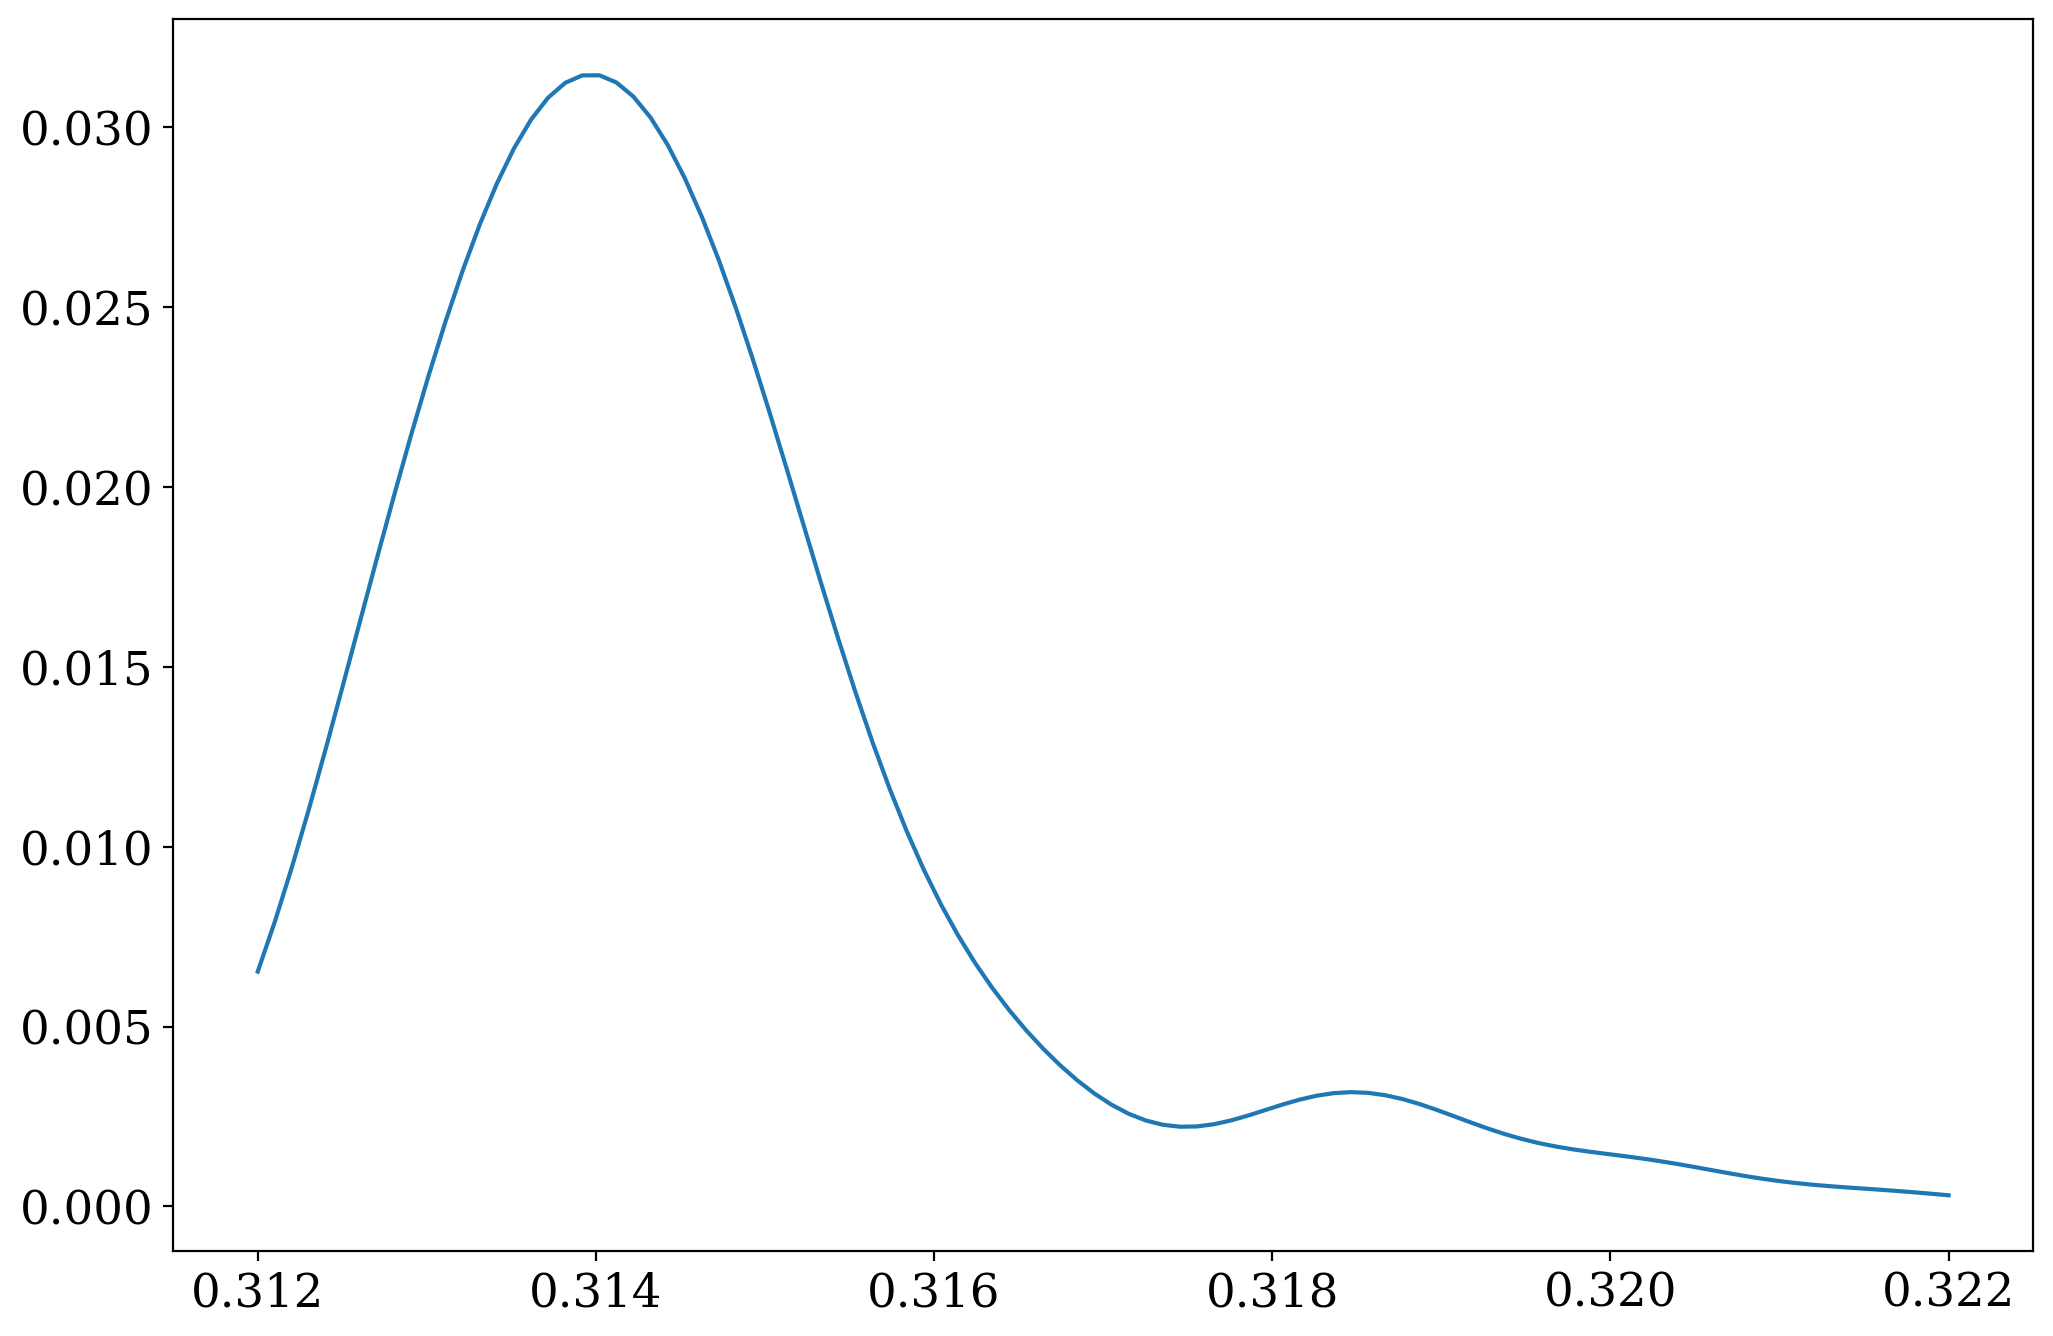

In [16]:
plt.plot(mc_range, mc_flo_interp(mc_range))

In [17]:
apyconst.M_sun

<<class 'astropy.constants.iau2015.IAU2015'> name='Solar mass' value=1.988409870698051e+30 uncertainty=4.468805426856864e+25 unit='kg' reference='IAU 2015 Resolution B 3 + CODATA 2018'>

In [18]:
normfact = 1.3843284291803618e+34

## test at filling pop at certain freq given chirpmasses 

In [19]:
# now lets make a function that calculates the number of CVs at a given freq/chirp mass

def dNdfdmc_CVs_gwevol(f, mchirp):
    """_summary_

    Parameters
    ----------
    f : float
        frequency in Hz
    mchirp : float
        chirp mass in solar masses
    """
    # See eqn A2 of Nissanke et al. 2012
    # G, c in m, s, kg
    dfdt_fact = (96/5)*np.pow(np.pi, -8/3)*np.pow(apyconst.G.value, -5/3)*np.pow(apyconst.c.value, 5)
    # LSS convert chirp mass from solar masses to kg
    mc_kg = mchirp * apyconst.M_sun.value
    dfdt_vars = np.pow(mc_kg, -5/3)*np.pow(f, -11/3)
    dtdf = (dfdt_fact*dfdt_vars)**-1
    # print(dtdf)
    dNdmc = mc_flo_interp(mchirp)
    flo_norm = 1
    dNdfdmc = dtdf * dNdmc * normfact
    return dNdfdmc

In [20]:
# LSS sum over mass 
# mult by freq binsize and mass binsize to get total number
unnormN = np.sum(dNdfdmc_CVs_gwevol(np.array(flo), mc_range)) * df * (mc_range[1]-mc_range[0])

In [21]:
Fgrid, Mgrid = np.meshgrid([flo, fhi], mc_range)

In [22]:
tstN = dNdfdmc_CVs_gwevol(Fgrid, Mgrid)

In [23]:
tstN.shape

(100, 2)

In [24]:
tstNflo = np.sum(tstN[:, 0])

In [25]:
mcbinsize = mc_range[1]-mc_range[0]
tstNflo * mcbinsize * df # LSS need to multiply by binsize because we are calculating a density and need to convert to a real number.

np.float64(177.0)

In [26]:
tstNfhi = np.sum(tstN[:, 1])

In [27]:
mcbinsize = mc_range[1]-mc_range[0]
Nfhi_est = tstNfhi * mcbinsize * df # LSS need to multiply by binsize because we are calculating a density and need to convert to a real number.

In [28]:
counts

array([ 277.,  333.,  402.,  177.,    0.,  579., 1147., 1221., 1433.,
       1715.])

make some figures out of this with filled populations
write this up and send to katie and steve 
bootstrap over mc and f binning to get uncertainties
be careful of bin edges 

not sure how to do it
conditioning this on poisson realization of the rate in the previous bin
getting rate from previous bin
what we have computed is estimated rate in connecting bins
- poisson realizations from estimated rate to get uncertainties

lets do this not worrying about first bin being poisson realization so far

In [29]:
bins[np.where(counts==0)[0]]

array([0.00020635])

In [30]:
emptyfbin = bins[np.where(counts==0)[0]]

In [31]:
Fgrid, Mgrid = np.meshgrid([emptyfbin], mc_range)
tstN = dNdfdmc_CVs_gwevol(Fgrid, Mgrid)
mcbinsize = mc_range[1]-mc_range[0]
fillnum = np.sum(tstN, axis=0) * mcbinsize * df # LSS need to multiply by binsize because we are calculating a density and need to convert to a real number.


In [32]:
filledcts = copy.deepcopy(counts)
filledcts[4] = fillnum[0]
filledcts[5] = Nfhi_est

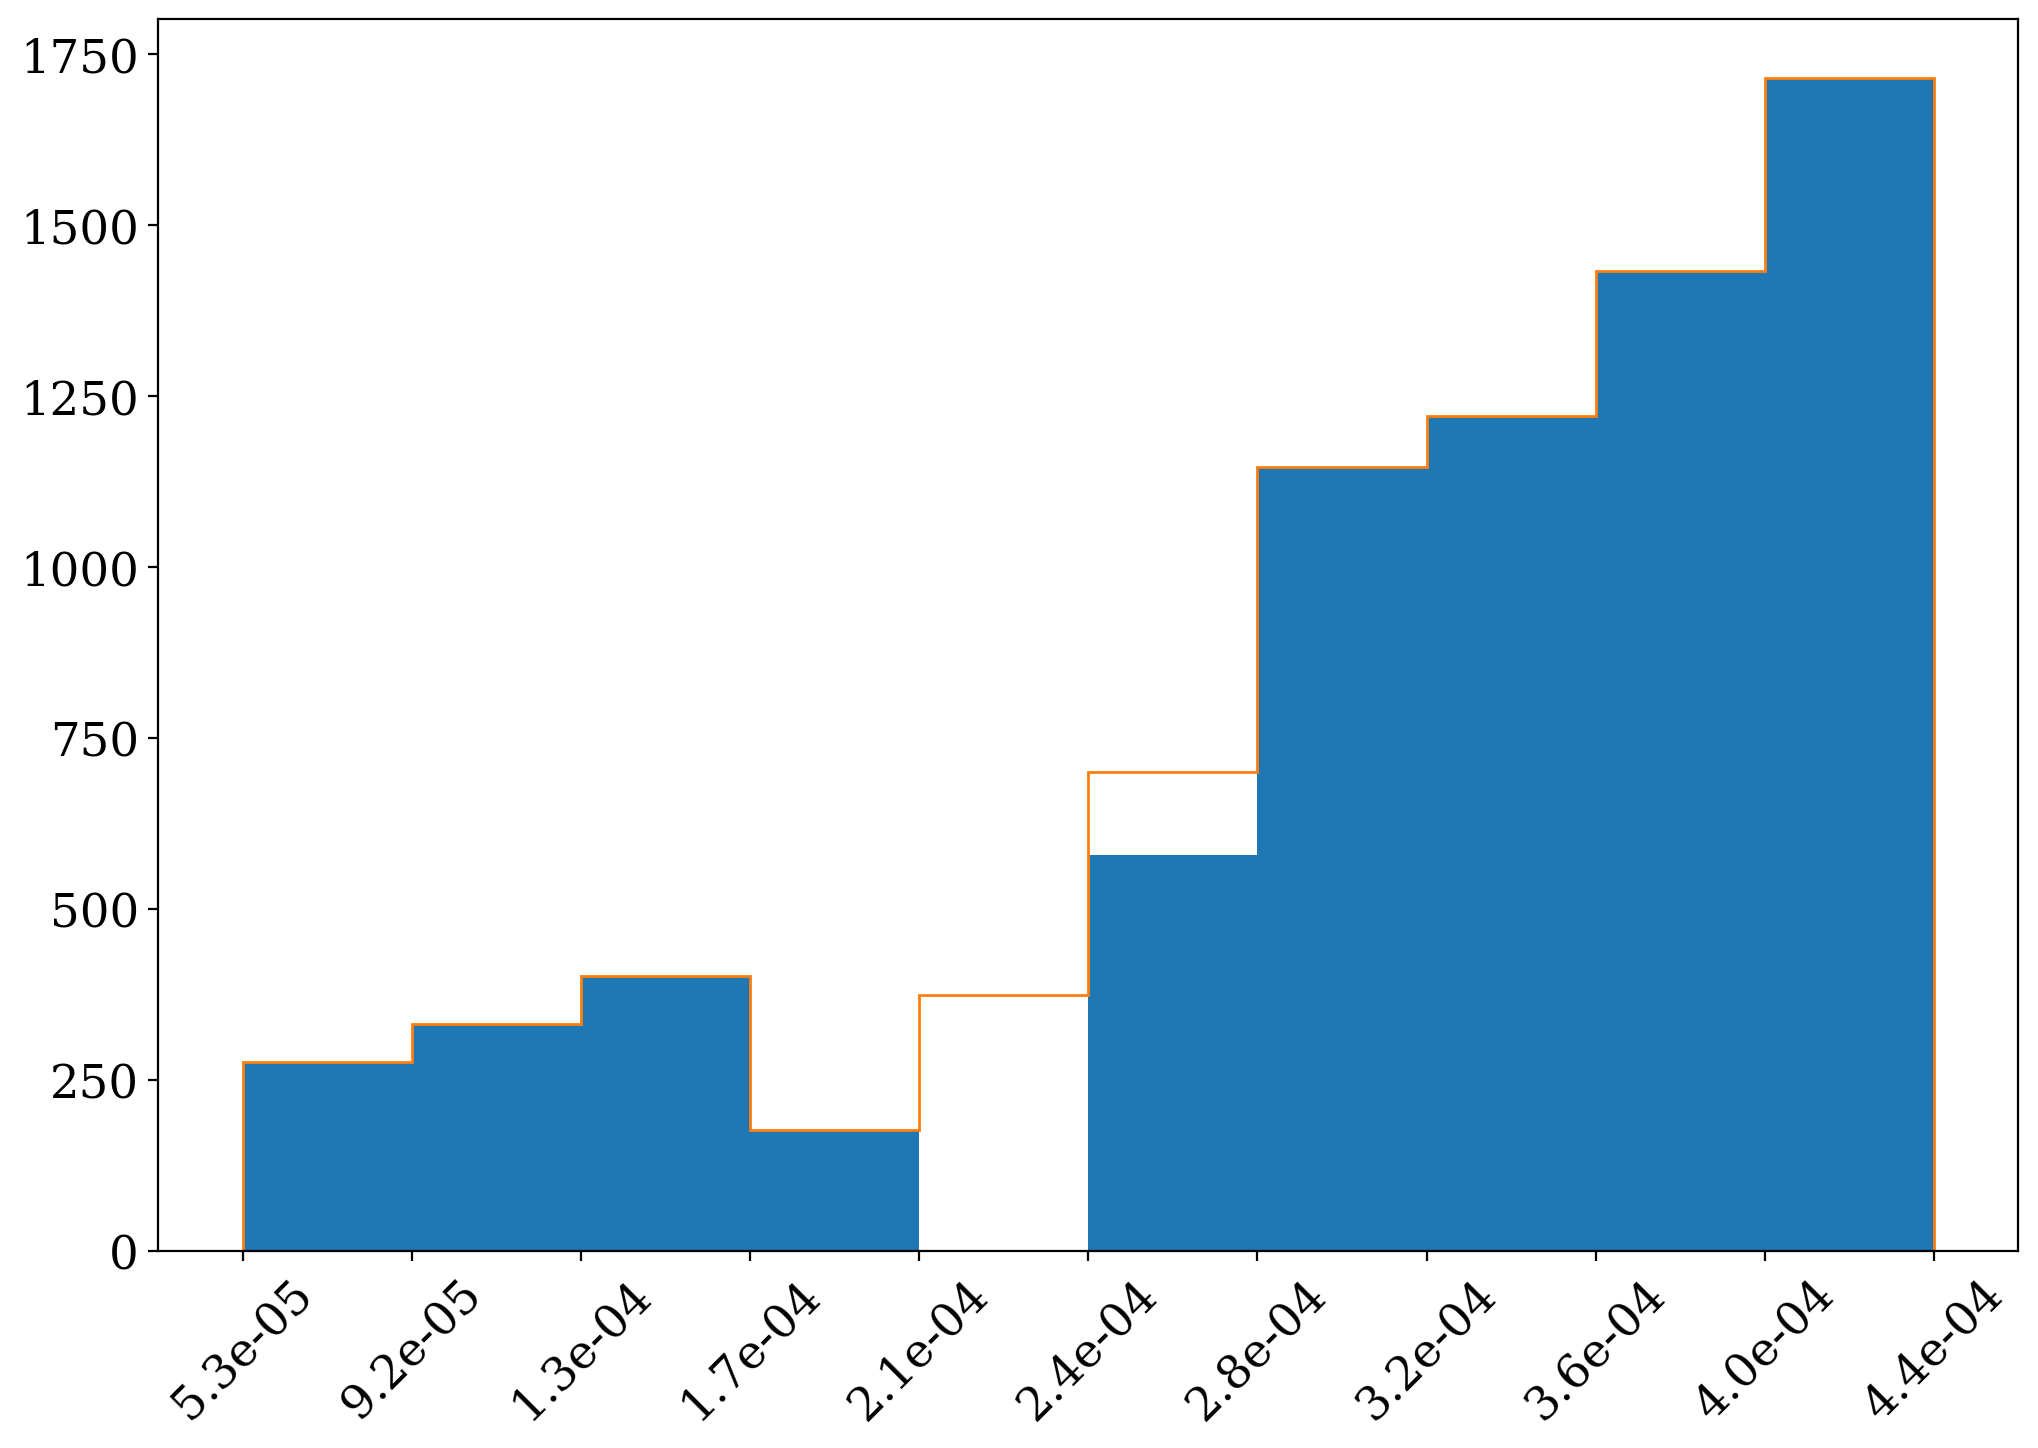

In [33]:
fig, ax = plt.subplots()
ax.stairs(counts, bins, fill=True)
ax.stairs(filledcts, bins)
ax.set_xticks(bins)
ax.set_xticklabels([f'{b:.1e}' for b in bins], rotation=45);

## make general purpose funcs

In [75]:
# now lets make a function that calculates the number of CVs at a given freq/chirp mass
# lets include freq bin and chirp mass bins to get true number rather than density
# also will create meshgrid from input arrays now

def dNdmchirp(cvpop, Nbins, freqcolname=' f_gw[Hz]', mass1colname='# m1[Msun]', mass2colname=' m2[Msun]'):
    """
    Create chirp mass distribution from given CV population using KDE.

    Nbins is used to bin the CVs according to frequency, this function then 
    finds the lowest frequency bin before the EM freq gap and uses the CVs in 
    that bin to form a chirp mass distribution using a KDE. This distribution
    is then returned as an interpolation function and can be used to fill the 
    missing CV population in the EM gap using the N_CVs_gwevol function.

    Parameters
    ----------
    cvpop : DataFrame
        DataFrame containing CV population data.
    Nbins : int
        Number of bins for CV population.
    freqcolname : str, optional
        Column name for frequency in the CV population DataFrame 
        (default is ' f_gw[Hz]').
    mass1colname : str, optional
        Column name for primary mass in the CV population DataFrame
        (default is '# m1[Msun]').
    mass2colname : str, optional
        Column name for secondary mass in the CV population DataFrame
        (default is ' m2[Msun]').

    Returns
    -------
    mc_interp : scipy.interpolate.interp1d (function)
        Interpolation of chirp mass distribution at lowest frequency bin.
        to get value at mchirp_val, use mc_interp(mchirp_val).
    """
    # LSS bin up the CV population to find EM gap
    counts, bins = np.histogram(cvpop[freqcolname], bins=Nbins)
    emgap_inds = np.where(counts==0)[0] # LSS get indices of EM gap
    flo_ind = emgap_inds[0]-1 # LSS get index of lowest freq bin before gap
    flo = bins[flo_ind]
    df = bins[1]-bins[0]
    
    # LSS get the CVs in flo
    flo_CVs_ind = np.where((CV_pop[freqcolname]>bins[ind_flo]) &
                    (CV_pop[freqcolname]<bins[ind_flo]+df))[0]
    flo_CVs = cvpop.iloc[flo_CVs_ind]
    
    # LSS check that we recovered the right number of CVs
    if flo_CVs_ind.shape[0] != counts[flo_ind]:
        raise Exception('Number of CVs in flo bin does not match histogram count!')

    flo_mc = lw.utils.chirp_mass(flo_CVs[mass1colname] * u.Msun, flo_CVs[mass2colname] * u.Msun)
    
    kern = 'gaussian'
    
    bwrange = np.linspace(1e-9, 1e-3, 1000) # 
    K = 20 # Do 20-fold cross validation
    grid = GridSearchCV(KernelDensity(kernel=kern), {'bandwidth': bwrange}, cv=K) 
    
    # LSS find optimal bandwidth based on chirp mass distribution at flo
    grid.fit(np.array(flo_mc)[:, None]) 
    h_opt = grid.best_params_['bandwidth']
    print(f"Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: {h_opt}")

    mc_range = np.linspace(min(flo_mc), max(flo_mc), 100)
    mc_kde = KernelDensity(kernel=kern, bandwidth=h_opt).fit(np.array(flo_mc)[:, None])
    log_dens = mc_kde.score_samples(mc_range[:, None])
    
    # normalize
    mc_interp = interpolate.interp1d(mc_range, np.exp(log_dens)/np.sum(np.exp(log_dens)))
    
    return mc_interp



def N_CVs_gwevol(f, mchirp, Nbin, cvpop=CV_pop):
    """
    Calculate the number of CVs at given frequencies assuming only GW evolution.

    This function assumes the chirp mass distribution is the same as that at the
    lowest frequency bin before the EM freq gap.

    NOTE: currently the chirp mass distribution comes from binning the binaries 
    into 10 freq bins. Future item will regenerate flo chirp mass distribution 
    based on the input freq binning.

    Parameters
    ----------
    f : array
        array of frequencies in Hz
    mchirp : array
        array of chirp masses in solar masses
    
    Returns
    -------
    N : array
        number of CVs at each frequency (summed over chirp mass)
    """
    # LSS get df and dm for converting later density to number
    df = f[1]-f[0]
    dm = mchirp[1]-mchirp[0]

    # LSS create meshgrid from input arrays
    Fgrid, Mgrid = np.meshgrid(f, mchirp)

    # LSS skip this for now...
    # LSS get chirp mass distribution at lowest freq bin before EM gap
    # CVcts, _ = np.hist(CV_pop[' f_gw[Hz]'], bins=f)

    # See eqn A2 of Nissanke et al. 2012
    # G, c in m, s, kg
    dfdt_fact = (96/5)*np.pow(np.pi, -8/3)*np.pow(apyconst.G.value, -5/3)*np.pow(apyconst.c.value, 5)

    # LSS convert chirp mass from solar masses to kg
    mc_kg = Mgrid * apyconst.M_sun.value
    dfdt_vars = np.pow(mc_kg, -5/3)*np.pow(Fgrid, -11/3)
    dtdf = (dfdt_fact*dfdt_vars)**-1
    # LSS get chirp mass distribution based on input binning of CV population
    dNdmc_func = dNdmchirp(cvpop, Nbin)
    try:
        dNdmc = dNdmc_func(Mgrid)
    except ValueError:
        print("Chirp mass values out of interpolation range, setting those values to zero.")
        dNdmc = np.zeros_like(Mgrid)
        mchirp_min = min(dNdmc_func.x)
        mchirp_max = max(dNdmc_func.x)
        print(f"Chirp mass interpolation range: {mchirp_min} - {mchirp_max} Msun")
        valid_inds = np.where((Mgrid >= mchirp_min) & (Mgrid <= mchirp_max))
        dNdmc[valid_inds] = dNdmc_func(Mgrid[valid_inds])
    
    print(dNdmc)
    N = dtdf * dNdmc * normfact * df * dm
    # LSS Sum over chirp mass to get total number at each frequency
    N = np.sum(N, axis=0)  
    return N

## test general purpose function with 20 bins for f binning CV pop

In [76]:
counts20, bins20 = np.histogram(CV_pop[' f_gw[Hz]'], bins=20)

In [87]:
abcd = [np.where(counts20 == 0)[0][0]-1].extend(np.where(counts20 == 0)[0])

In [88]:
abcd

In [79]:
# LSS get the mchirp range from the interpolation
dndmc_func = dNdmchirp(CV_pop, Nbins=20)
mc_range = np.linspace(dndmc_func.x[0], dndmc_func.x[-1], 10)

N_CVs_gwevol(bins20[np.where(counts20 == 0)[0]], mc_range, Nbin=20)

Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
Optimal bandwidth for chirp mass KDE at lowest frequency bin before EM gap: 0.001
[[0.00464193 0.00464193 0.00464193 0.00464193]
 [0.01128746 0.01128746 0.01128746 0.01128746]
 [0.00989772 0.00989772 0.00989772 0.00989772]
 [0.00699797 0.00699797 0.00699797 0.00699797]
 [0.01385055 0.01385055 0.01385055 0.01385055]
 [0.01420288 0.01420288 0.01420288 0.01420288]
 [0.0178735  0.0178735  0.0178735  0.0178735 ]
 [0.00442143 0.00442143 0.00442143 0.00442143]
 [0.00862952 0.00862952 0.00862952 0.00862952]
 [0.00507435 0.00507435 0.00507435 0.00507435]]


array([2115.56611007, 3022.18725105, 4182.8865312 , 5638.07708881])

(array([134., 143., 156., 177., 191., 211., 177.,   0.,   0.,   0.,   0.,
        579., 554., 593., 622., 599., 682., 751., 780., 935.]),
 array([5.3337200e-05, 7.2463270e-05, 9.1589340e-05, 1.1071541e-04,
        1.2984148e-04, 1.4896755e-04, 1.6809362e-04, 1.8721969e-04,
        2.0634576e-04, 2.2547183e-04, 2.4459790e-04, 2.6372397e-04,
        2.8285004e-04, 3.0197611e-04, 3.2110218e-04, 3.4022825e-04,
        3.5935432e-04, 3.7848039e-04, 3.9760646e-04, 4.1673253e-04,
        4.3585860e-04]),
 <BarContainer object of 20 artists>)

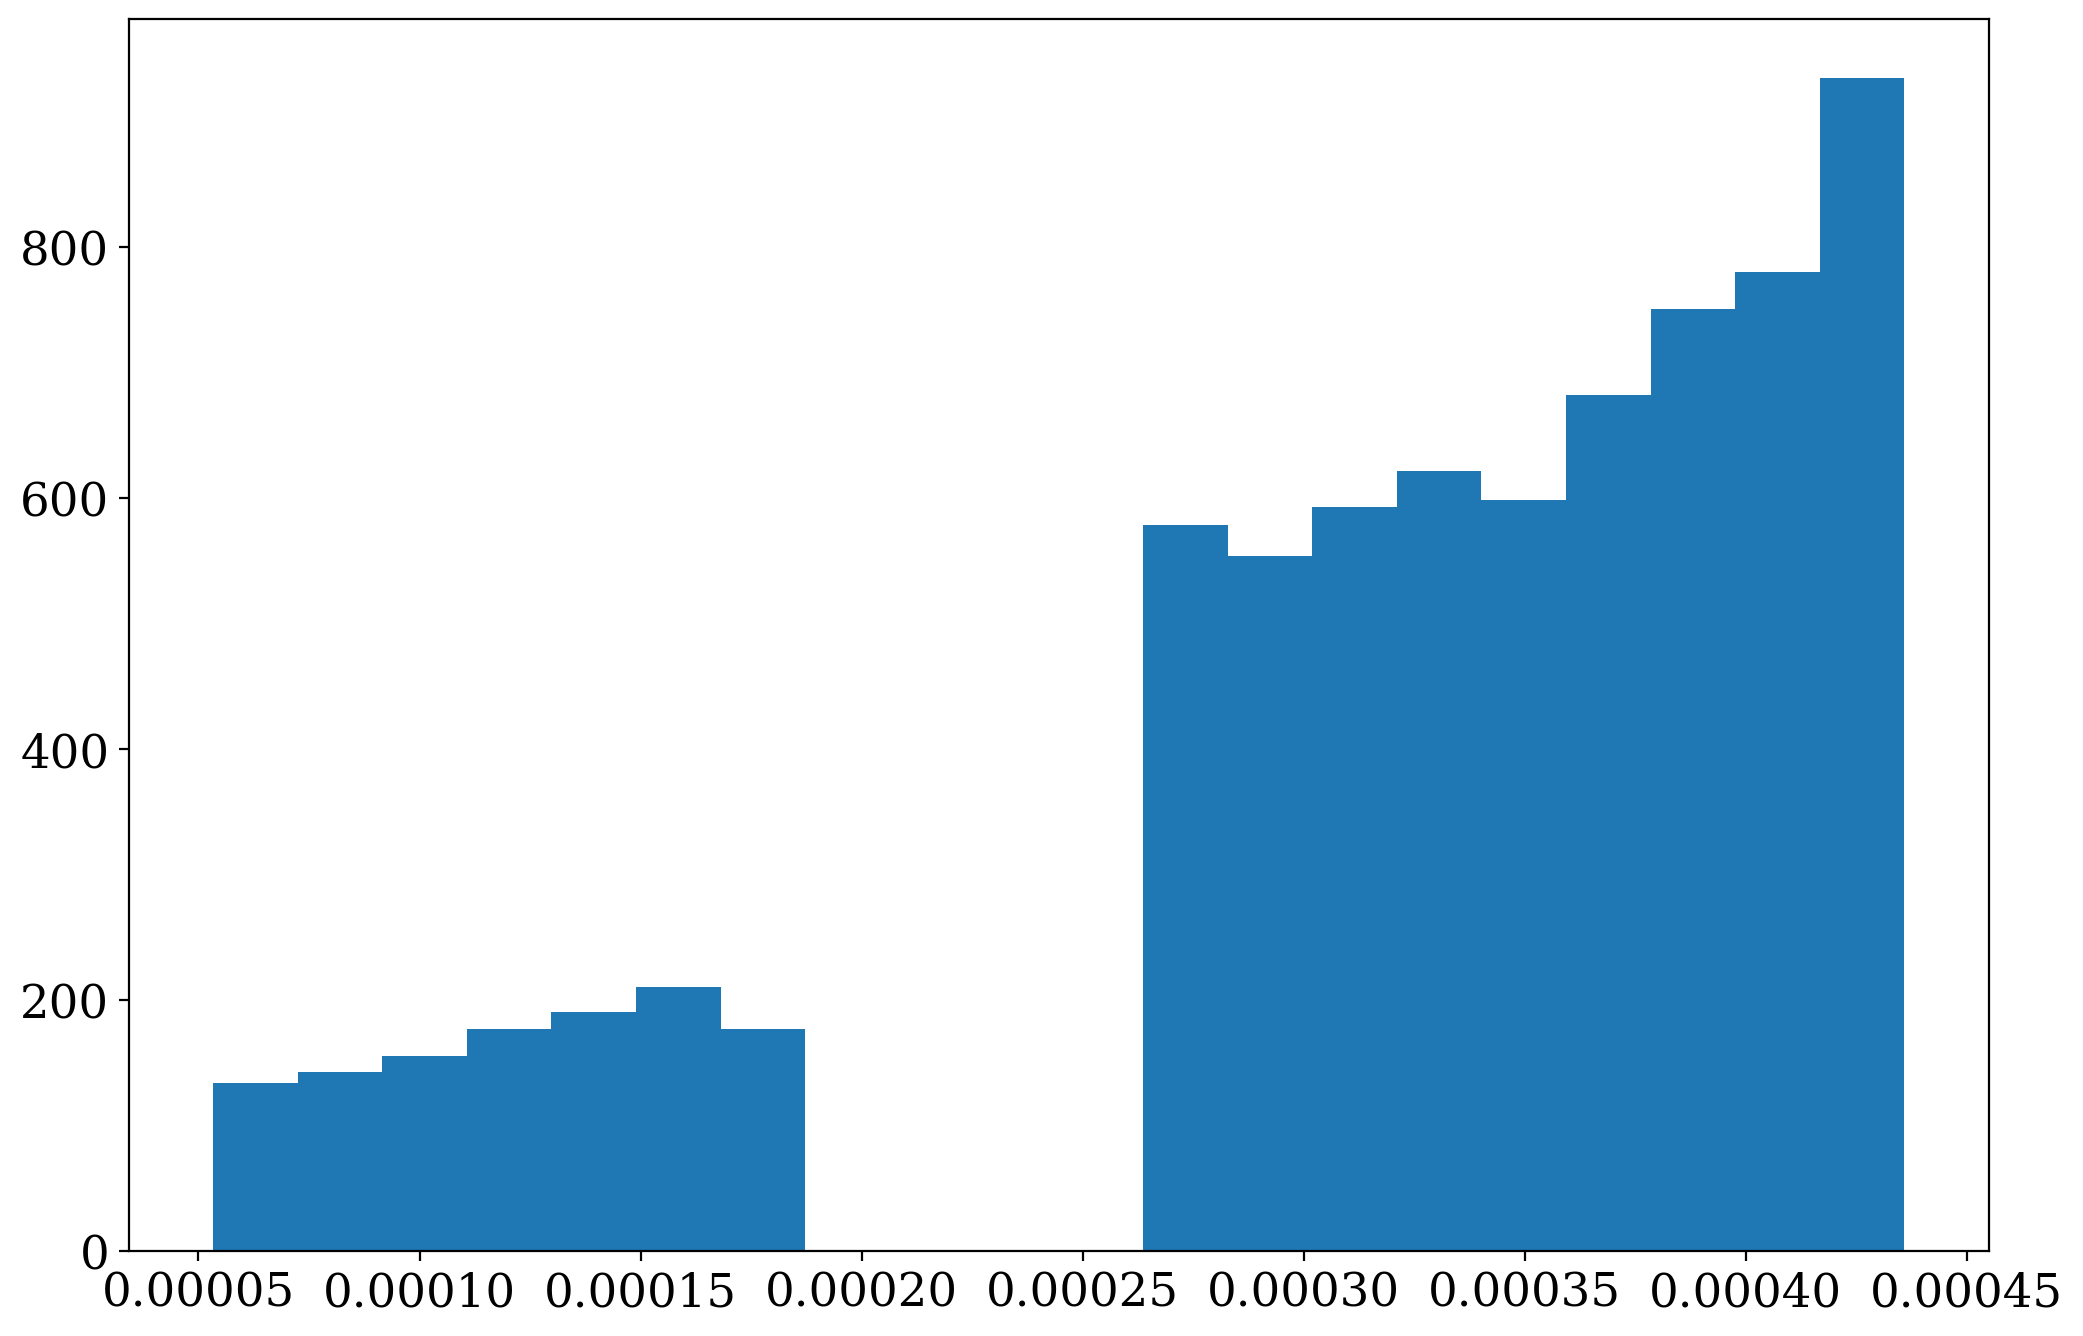

In [ ]:
plt.hist(CV_pop[' f_gw[Hz]'], bins=20)

In [ ]:
fig, ax = plt.subplots()
ax.stairs(counts, bins, fill=True)
ax.stairs(filledcts, bins)
ax.set_xticks(bins)
ax.set_xticklabels([f'{b:.1e}' for b in bins], rotation=45);

In [ ]:
# LSS test here -- do different binning of chirp mass and freq around period gap.....
